# Task 3: Car Price Prediction with Machine Learning
**Zoya Chaudhary** | Data Science Internship, Oasis Infobyte SIP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('car_data.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [3]:
df.isnull().sum()
df.duplicated().sum()

np.int64(1202)

Data quality check: df.duplicated().sum() returns 1,202 that's roughly 15% of the dataset is duplicate rows. mileage, engine, max_power, and torque are stored as object dtype due to embedded units (e.g. "23.4 kmpl", "1248 CC"), and require parsing before use in modeling. Missing values are concentrated in the same four columns plus seats.

df[df.duplicated(keep=False)].sort_values('name').head(20)

In [4]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [5]:
df = df.drop_duplicates()
df.shape

(6926, 13)

In [6]:
df['mileage'].str.split(' ').str[1].value_counts()

mileage
kmpl     6631
km/kg      87
Name: count, dtype: int64

In [7]:
df[df['max_power'].str.split(' ').str[0] == '']['max_power']

4933     bhp
Name: max_power, dtype: object

In [8]:
def extract_numeric(series):
    if series.dtype == 'object':
        series = series.str.split(' ').str[0]
    return pd.to_numeric(series, errors='coerce')

In [9]:
df['mileage'] = extract_numeric(df['mileage'])
df['engine'] = extract_numeric(df['engine'])
df['max_power'] = extract_numeric(df['max_power'])

In [10]:
df[['mileage', 'engine', 'max_power']].dtypes

mileage      float64
engine       float64
max_power    float64
dtype: object

In [11]:
df[['mileage', 'engine', 'max_power']].isnull().sum()

mileage      208
engine       208
max_power    206
dtype: int64

In [12]:
df['torque'].str.contains('kgm', case=False, na=False).sum()
df['torque'].str.contains('Nm', case=False, na=False).sum()

np.int64(6227)

In [13]:
import re

def extract_torque_nm(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'[\d.,]+', str(value))
    if not match:
        return np.nan
    number = float(match.group().replace(',', ''))
    if 'kgm' in str(value).lower():
        number *= 9.80665
    return number

df['torque'] = df['torque'].apply(extract_torque_nm)

In [14]:
df['torque'].dtype
df['torque'].isnull().sum()
df['torque'].describe()

count    6717.000000
mean      175.182802
std       115.301539
min        47.071920
25%       110.000000
50%       160.000000
75%       200.055660
max      3726.527000
Name: torque, dtype: float64

In [15]:
raw_torque = pd.read_csv('car_data.csv')['torque']

In [16]:
suspicious = df[df['torque'] > 1000].index
raw_torque.loc[suspicious].head(10)

604        115@ 2,500(kgm@ rpm)
778     380Nm(38.7kgm)@ 2500rpm
1211       145@ 4,100(kgm@ rpm)
2086       115@ 2,500(kgm@ rpm)
2289       145@ 4,100(kgm@ rpm)
2314       145@ 4,100(kgm@ rpm)
2421        130@ 2500(kgm@ rpm)
2880        130@ 2500(kgm@ rpm)
4149       145@ 4,100(kgm@ rpm)
4309       145@ 4,100(kgm@ rpm)
Name: torque, dtype: object

In [17]:
def extract_torque_nm(value):
    if pd.isna(value):
        return np.nan
    s = str(value)
    # first choice: a number with its unit directly attached (e.g. "380Nm", "22.4 kgm")
    match = re.search(r'([\d.,]+)\s*(nm|kgm)', s, re.IGNORECASE)
    if match:
        number = float(match.group(1).replace(',', ''))
        unit = match.group(2).lower()
    else:
        # fallback: no unit directly attached to the number, infer from anywhere in string
        match = re.search(r'[\d.,]+', s)
        if not match:
            return np.nan
        number = float(match.group().replace(',', ''))
        unit = 'kgm' if 'kgm' in s.lower() else 'nm'
    if unit == 'kgm':
        number *= 9.80665
    return number

df['torque'] = raw_torque.apply(extract_torque_nm)

In [18]:
df['torque'].describe()

count    6717.000000
mean      174.684585
std       106.876249
min        47.071920
25%       110.000000
50%       160.000000
75%       200.055660
max      1863.263500
Name: torque, dtype: float64

In [19]:
suspicious = df[df['torque'] > 1000].index
suspicious

Index([ 604, 1211, 2086, 2289, 2314, 2421, 2880, 4149, 4309, 4454, 4629, 4971,
       4987, 4996, 5029, 5242, 5415, 5635, 6772, 6918, 7743],
      dtype='int64')

In [20]:
raw_torque.loc[suspicious]

604      115@ 2,500(kgm@ rpm)
1211     145@ 4,100(kgm@ rpm)
2086     115@ 2,500(kgm@ rpm)
2289     145@ 4,100(kgm@ rpm)
2314     145@ 4,100(kgm@ rpm)
2421      130@ 2500(kgm@ rpm)
2880      130@ 2500(kgm@ rpm)
4149     145@ 4,100(kgm@ rpm)
4309     145@ 4,100(kgm@ rpm)
4454      115@ 2500(kgm@ rpm)
4629     145@ 4,100(kgm@ rpm)
4971     115@ 2,500(kgm@ rpm)
4987     145@ 4,100(kgm@ rpm)
4996     110@ 3,000(kgm@ rpm)
5029     145@ 4,100(kgm@ rpm)
5242     115@ 2,500(kgm@ rpm)
5415    190@ 21,800(kgm@ rpm)
5635     145@ 4,100(kgm@ rpm)
6772      130@ 2500(kgm@ rpm)
6918      130@ 2500(kgm@ rpm)
7743     145@ 4,100(kgm@ rpm)
Name: torque, dtype: object

In [21]:
raw_torque.loc[suspicious].value_counts()

torque
145@ 4,100(kgm@ rpm)     10
115@ 2,500(kgm@ rpm)      4
130@ 2500(kgm@ rpm)       4
115@ 2500(kgm@ rpm)       1
110@ 3,000(kgm@ rpm)      1
190@ 21,800(kgm@ rpm)     1
Name: count, dtype: int64

In [22]:
import re

corrupt_pattern = re.compile(r'^\d+@\s*[\d,]+\(kgm@\s*rpm\)$', re.IGNORECASE)

def is_corrupt(value):
    return bool(corrupt_pattern.match(str(value).strip()))

corrupt_mask = raw_torque.apply(is_corrupt)
corrupt_mask.sum()

np.int64(56)

In [23]:
df.loc[corrupt_mask, 'torque'] = np.nan
df['torque'].describe()

count    6663.000000
mean      171.066729
std        84.759525
min        47.071920
25%       110.000000
50%       160.000000
75%       200.055660
max       789.000000
Name: torque, dtype: float64

In [24]:
df[['mileage', 'engine', 'max_power', 'torque', 'seats']].isnull().sum()

mileage      208
engine       208
max_power    206
torque       263
seats        208
dtype: int64

In [25]:
df[['mileage', 'engine', 'max_power', 'torque', 'seats']].isnull().sum() / len(df) * 100

mileage      3.003176
engine       3.003176
max_power    2.974300
torque       3.797286
seats        3.003176
dtype: float64

In [26]:
df = df.dropna(subset=['mileage', 'engine', 'max_power', 'torque', 'seats'])
df.shape

(6663, 13)

In [27]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

Dropped rows missing mileage, engine, max_power, torque, or seats, combined this was only ~3-4% of the data, and the overlap between missing columns suggested these were listings with an entirely incomplete spec block rather than five unrelated data issues, so imputing each column separately wasn't worth the added complexity.

In [28]:
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(col, ':', df[col].unique())
    print()

fuel : ['Diesel' 'Petrol' 'LPG' 'CNG']

seller_type : ['Individual' 'Dealer' 'Trustmark Dealer']

transmission : ['Manual' 'Automatic']

owner : ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']



In [29]:
df['name'].str.split().str[0].value_counts()

name
Maruti           2078
Hyundai          1214
Mahindra          700
Tata              618
Honda             360
Ford              346
Toyota            324
Chevrolet         208
Renault           206
Volkswagen        172
Nissan             73
Skoda              69
Datsun             57
BMW                45
Mercedes-Benz      44
Fiat               39
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Isuzu               4
Ambassador          4
Force               4
Land                3
Kia                 3
Daewoo              3
MG                  3
Ashok               1
Lexus               1
Opel                1
Name: count, dtype: int64

In [30]:
two_word_brands = {'Land': 'Land Rover', 'Ashok': 'Ashok Leyland'}

df['brand'] = df['name'].str.split().str[0]
df['brand'] = df['brand'].replace(two_word_brands)

df['brand'].value_counts()

brand
Maruti           2078
Hyundai          1214
Mahindra          700
Tata              618
Honda             360
Ford              346
Toyota            324
Chevrolet         208
Renault           206
Volkswagen        172
Nissan             73
Skoda              69
Datsun             57
BMW                45
Mercedes-Benz      44
Fiat               39
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Isuzu               4
Ambassador          4
Force               4
Land Rover          3
Kia                 3
Daewoo              3
MG                  3
Ashok Leyland       1
Lexus               1
Opel                1
Name: count, dtype: int64

In [31]:
df['car_age'] = df['year'].max() - df['year']
df[['name', 'brand', 'year', 'car_age']].head()

,name,brand,year,car_age
0,Maruti Swift Dzire VDI,Maruti,2014,6
1,Skoda Rapid 1.5 TDI Ambition,Skoda,2014,6
2,Honda City 2017-2020 EXi,Honda,2006,14
3,Hyundai i20 Sportz Diesel,Hyundai,2010,10
4,Maruti Swift VXI BSIII,Maruti,2007,13


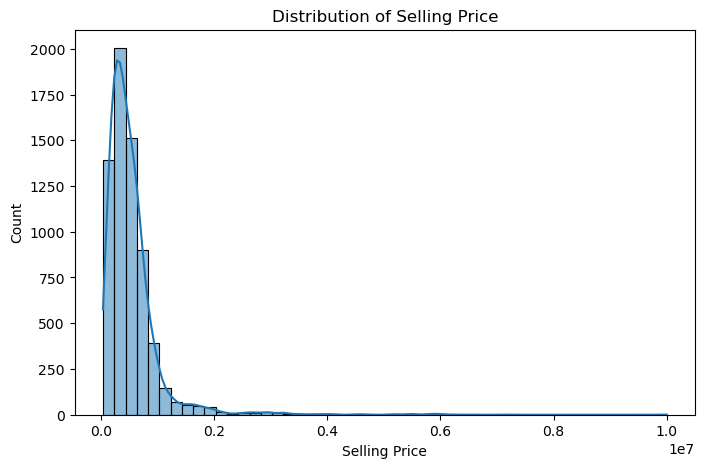

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

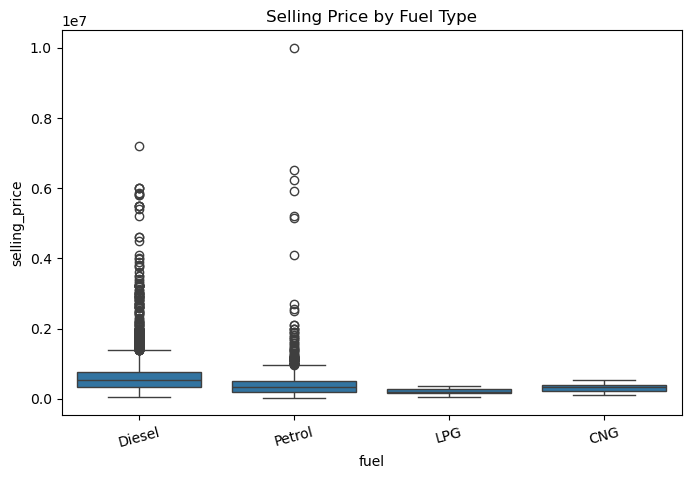

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='fuel', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.xticks(rotation=15)
plt.show()

Diesel cars clearly command the highest prices here, followed by Petrol, with LPG and CNG sitting much lower and tighter. Diesel also has the widest spread of high-price outliers and it makes sense since diesel engines have historically cost more upfront in India and tend to be found in bigger/premium vehicles (SUVs, higher trims). What's worth noting though: LPG and CNG only make up a tiny fraction of the dataset (checked back on my .unique() counts), so their narrow boxes are partly just a small-sample effect, so I wouldn't read too much into them having a hard price ceiling, there's just not enough data there to show much spread.

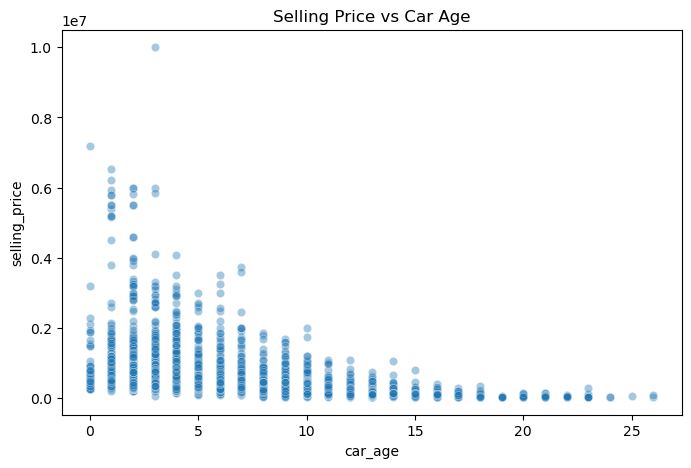

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='car_age', y='selling_price', alpha=0.4)
plt.title('Selling Price vs Car Age')
plt.show()

There's a clear negative relationship between car_age and selling_price, but it's not linear it drops sharply in the first ~5 years, then flattens out a lot after that. Makes sense: a car loses the most value early on, and once it's 15-20 years old, further aging barely changes the resale price (it's already low). This suggests a model that can capture curves, not just straight-line relationships, might fit this data better than plain Linear Regression.

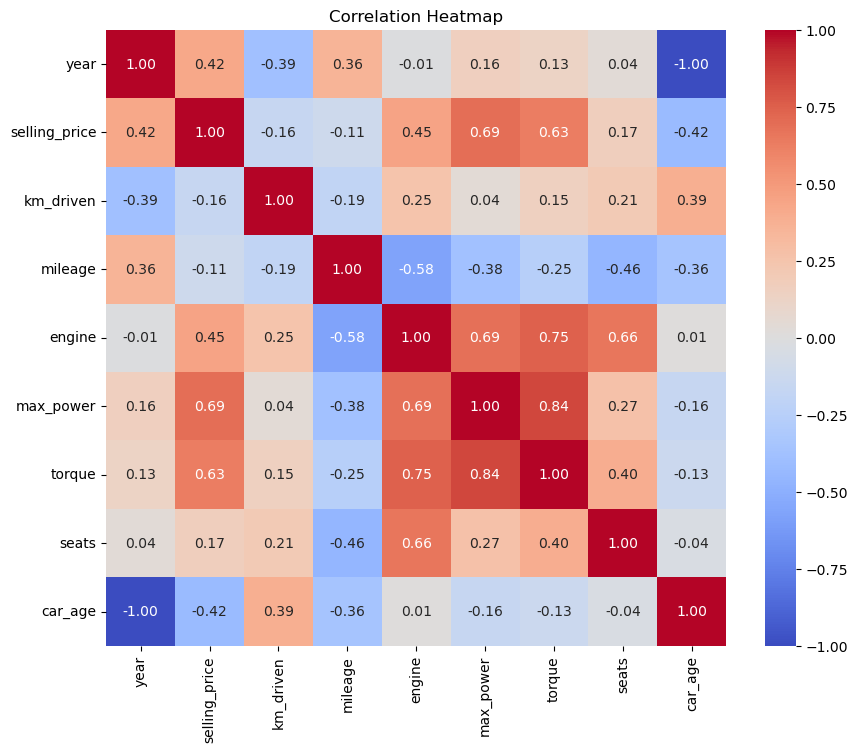

In [35]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Confirms what the earlier charts suggested selling_price correlates most with max_power (0.69), torque (0.63), and engine (0.45), and negatively with car_age (-0.42).

year and car_age are perfectly correlated (-1.00), which makes sense since I derived one from the other, I'll only use car_age going forward to avoid feeding the model duplicate information.

engine, max_power, and torque are all fairly correlated with each other (0.69–0.84), which tracks physically, so bigger engines mean more power and torque. Linear Regression coefficients could be a bit unstable, it shouldn't matter for Random Forest.

Interesting one: mileage is negatively correlated with selling_price. Makes sense once you think about it as fuel-efficient cars are usually smaller/cheaper hatchbacks, while pricier SUVs trade mileage for power.

In [36]:
df['brand'].nunique()

31

fuel, seller_type, transmission, and brand are nominal, with no inherent order so I one-hot encoded them with drop_first=True to avoid the dummy variable trap.

In [37]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

owner is ordinal, but I ranked it by wear rather than raw count: Test Drive Car ranks lowest (0), since dealership demo units typically have less wear than even a first-owner car. First → Fourth & Above follow in increasing order after that.

Dropping year going forward and it's perfectly correlated with car_age, so keeping both adds no signal.

In [38]:
owner_order = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
df['owner_encoded'] = df['owner'].map(owner_order)
df_encoded = pd.get_dummies(
    df,
    columns=['fuel', 'seller_type', 'transmission', 'brand'],
    drop_first=True
)
df_encoded.shape

(6663, 48)

In [39]:
df_encoded.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage',
       'engine', 'max_power', 'torque', 'seats', 'car_age', 'owner_encoded',
       'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'brand_Ashok Leyland', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet',
       'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu',
       'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover',
       'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti',
       'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel',
       'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'brand_Volvo'],
      dtype='object')

In [40]:
df_model = df_encoded.drop(columns=['name', 'year', 'owner'])
df_model.shape

(6663, 45)

In [41]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['selling_price'])
y = df_model['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5330, 44), (1333, 44))

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression
MAE:  136,204.86
RMSE: 245,039.44
R²:   0.7286


R² of 0.73 decent starting point, but RMSE (245K) is almost double MAE (136K), meaning a handful of predictions are way off rather than errors being evenly spread. This lines up with the right-skew I flagged in EDA. The model is likely underpredicting high-end cars since it's fitting a straight line to a non-linear price distribution. Expecting Random Forest to close this gap.

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

Random Forest
MAE:  70,485.52
RMSE: 126,208.70
R²:   0.9280


R² jumps to 0.93 from 0.73, MAE nearly halves (70K vs 136K), RMSE drops from 245K to 126K. Confirms the theory that Random Forest handles the non-linear depreciation curve and right-skewed target far better than a straight-line model, and doesn't get tripped up by the engine/max_power/torque multicollinearity. Clear choice for the final model.

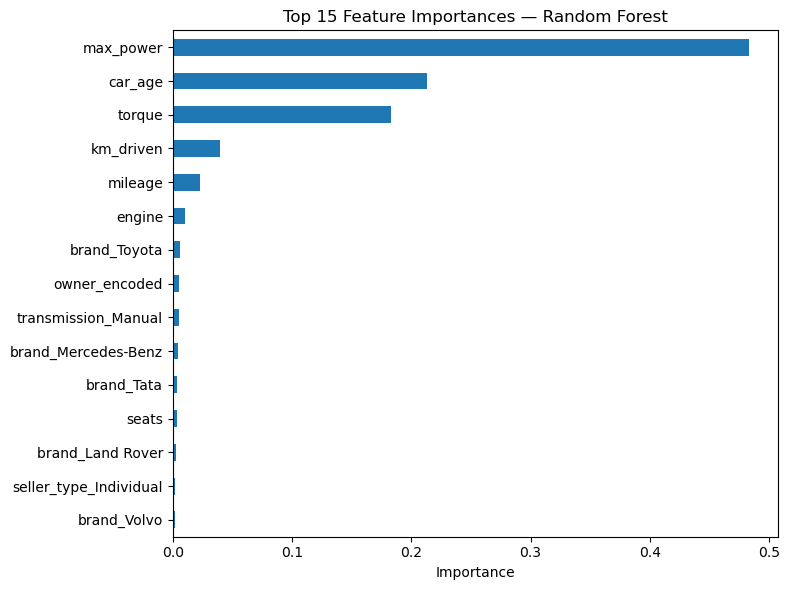

In [45]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

max_power alone accounts for ~48% of the model's importance, with car_age and torque next, together explaining most of the remaining signal. Everything past mileage/engine, individual brands, seller_type, and transmission barely registers. This matches the correlation heatmap from EDA almost exactly: max_power (0.69), torque (0.63), and car_age (-0.42) were the strongest signals there too. Good confirmation that the model is learning genuine price drivers, not noise.

Individual brand_* dummies barely show up despite brand feeling intuitively important, that's likely because max_power/torque/car_age already capture why a brand is expensive (a Land Rover's price is driven by its powerful engine and premium specs, not the brand name itself as a separate signal).

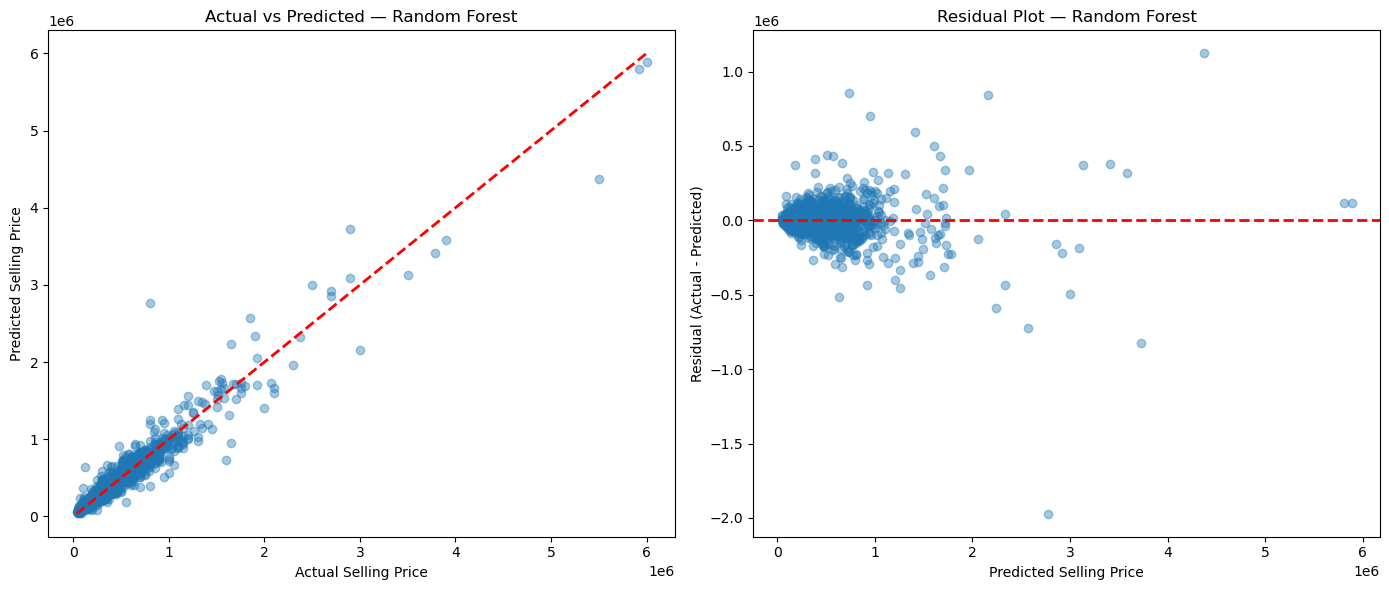

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Actual vs Predicted — Random Forest')

# Residual plot
residuals = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, alpha=0.4)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Selling Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot — Random Forest')

plt.tight_layout()
plt.show()

Predictions cluster tightly along the diagonal for most of the price range, confirming the strong R². But the residual plot shows a mild funnel, errors grow past ~₹15L predicted price, and there are a couple of standout outliers (one overpredicted by ~₹11L, one underpredicted by ~₹20L). The model handles the bulk of typical cars very well; expensive/rare cars remain the harder case, consistent with the original right-skew in selling_price.